In [11]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
import sys
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
import pyhepmc as hep
from pyhepmc.io import WriterAscii

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Configure paths and expected parameters
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

merged_path = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v4/runs/0/merged_events.hepmc3")
assert merged_path.exists(), f"Merged file not found: {merged_path}"

mu = 200.0
print("Merged file:", merged_path)
print("Expected Poisson mu:", mu)


Merged file: /global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup_pilot/ttbar/v4/runs/0/merged_events.hepmc3
Expected Poisson mu: 200.0


In [20]:
evt.numpy.vertices.status

array([0, 0, 0, ..., 0, 0, 0], shape=(50272,), dtype=int32)

In [27]:
(evt.numpy.particles.status == 4).sum() / 2

np.float64(204.0)

AttributeError: 'HepMCFile' object has no attribute 'numpy'

In [ ]:
# Use pyhepmc to read the merged events and estimate pileup multiplicity
import pyhepmc as hep

multiplicities = []
events_to_read = 10

with hep.open(str(merged_path)) as f:
    for i, evt in tqdm(enumerate(f)):
        # Count primary vertices as those with no incoming particles
        beam_particles = (evt.numpy.particles.status == 4).sum() / 2
        pileup_beam_particles = beam_particles - 1
        multiplicities.append(pileup_beam_particles)
        
        if i >= events_to_read:
            break

k = np.asarray(multiplicities, dtype=int) - 1
k = k[k >= 0]
print(f"Read {len(k)} events. k mean={k.mean():.2f}, std={k.std(ddof=1):.2f}")


9it [03:58, 27.89s/it]

Empirical mean=194.00, var=116.67 (expected mean=var≈200.00)


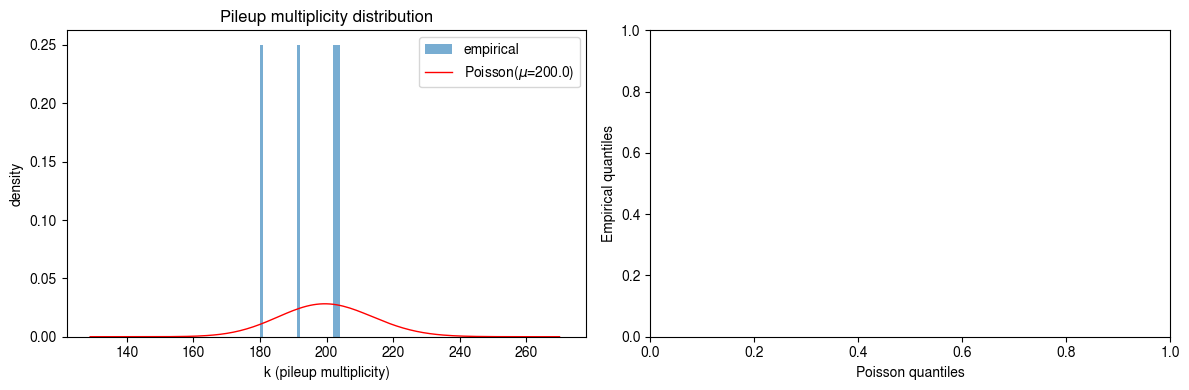

In [ ]:
# Plot histogram and compare to Poisson(mu)
import scipy.stats as st

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

if len(k):
    bins = np.arange(max(1, int(mu - 5*np.sqrt(mu))), int(mu + 5*np.sqrt(mu)) + 2)
    ax[0].hist(k, bins=bins, alpha=0.6, label="empirical", density=True)
    x = np.arange(bins[0], bins[-1])
    ax[0].plot(x, st.poisson(mu).pmf(x), 'r-', lw=1.0, label=f"Poisson($\\mu$={mu:.1f})")
    ax[0].legend()
    ax[0].set_ylabel("density")
ax[0].set_xlabel("k (pileup multiplicity)")
ax[0].set_title("Pileup multiplicity distribution")

emp_mean = float(np.mean(k)) if len(k) else float('nan')
emp_var = float(np.var(k, ddof=1)) if len(k) > 1 else float('nan')
print(f"Empirical mean={emp_mean:.2f}, var={emp_var:.2f} (expected mean=var≈{mu:.2f})")

if len(k) >= 10:
    empirical = np.sort(k)
    quantiles = np.linspace(0.01, 0.99, 50)
    q_emp = np.quantile(empirical, quantiles)
    q_pois = st.poisson(mu).ppf(quantiles)
    ax[1].plot(q_pois, q_emp, 'o', ms=3)
    ax[1].plot([q_pois.min(), q_pois.max()], [q_pois.min(), q_pois.max()], 'k--', lw=1)
    ax[1].set_title("Quantile-Quantile plot")
ax[1].set_xlabel("Poisson quantiles")
ax[1].set_ylabel("Empirical quantiles")
plt.tight_layout(); plt.show()
